# Evaluate Saved DANN Model on NINAPRO Subject 1

This notebook loads the trained model components and preprocessing artifacts from Google Drive, preprocesses **Subject 1** with the saved scaler, and reports the subject-specific accuracy.

Expected files in `MODEL_DIR`:
- `dann_feature_extractor_all_new.keras`
- `dann_gesture_classifier_all_new.keras`
- `scaler_subject_01.pkl`
- `label_classes_new.npy`
- `preprocessing_config_new.json`

Set `DATASET_PATH` and `MODEL_DIR` in the paths cell if your Drive folders are different.


In [1]:
# Mount Drive & install/import dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q scipy scikit-learn matplotlib tqdm

import os
import glob
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.io
from scipy.signal import butter, filtfilt
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Layer, Dense
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


Mounted at /content/drive
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# =========================
# Paths and evaluation setup
# =========================

SUBJECT_ID = 27   # change this to 15, 27, etc. if you want another subject

DATASET_PATH = "/content/drive/MyDrive/NINAPRO"
MODEL_DIR = "/content/drive/MyDrive/models_grad_project"

FEATURE_EXTRACTOR_PATH = os.path.join(MODEL_DIR, "dann_feature_extractor_all_new_29.keras")
GESTURE_CLASSIFIER_PATH = os.path.join(MODEL_DIR, "dann_gesture_classifier_all_new_29.keras")

# New 29-label artifacts
LABEL_CLASSES_PATH = os.path.join(MODEL_DIR, "label_classes_new_29.npy")
PREPROCESSING_CONFIG_PATH = os.path.join(MODEL_DIR, "preprocessing_config_new_29.json")

paths_to_check = {
    "DATASET_PATH": DATASET_PATH,
    "FEATURE_EXTRACTOR_PATH": FEATURE_EXTRACTOR_PATH,
    "GESTURE_CLASSIFIER_PATH": GESTURE_CLASSIFIER_PATH,
    "LABEL_CLASSES_PATH": LABEL_CLASSES_PATH,
    "PREPROCESSING_CONFIG_PATH": PREPROCESSING_CONFIG_PATH,
}

for name, path in paths_to_check.items():
    if name == "DATASET_PATH":
        print(f"{name}: {path} ->", "OK" if os.path.isdir(path) else "NOT FOUND")
    else:
        print(f"{name}: {path} ->", "OK" if os.path.exists(path) else "NOT FOUND")

DATASET_PATH: /content/drive/MyDrive/NINAPRO -> OK
FEATURE_EXTRACTOR_PATH: /content/drive/MyDrive/models_grad_project/dann_feature_extractor_all_new_29.keras -> OK
GESTURE_CLASSIFIER_PATH: /content/drive/MyDrive/models_grad_project/dann_gesture_classifier_all_new_29.keras -> OK
LABEL_CLASSES_PATH: /content/drive/MyDrive/models_grad_project/label_classes_new_29.npy -> OK
PREPROCESSING_CONFIG_PATH: /content/drive/MyDrive/models_grad_project/preprocessing_config_new_29.json -> OK


In [3]:
# Custom layer required to load the saved DANN feature extractor.
# This matches the SEBlock used in the training notebook.

@tf.keras.utils.register_keras_serializable()
class SEBlock(Layer):
    def __init__(self, ratio=4, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.fc1 = Dense(max(channels // self.ratio, 1), activation="relu")
        self.fc2 = Dense(channels, activation="sigmoid")

    def call(self, x):
        squeeze = tf.reduce_mean(x, axis=1)
        excite = self.fc2(self.fc1(squeeze))
        return x * tf.expand_dims(excite, 1)

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config


class NinaProLoader:
    def __init__(self, path, use_channels):
        self.path = path
        self.use_channels = use_channels

    def _find_exercise_file(self, subject_id, exercise):
        # Find S{subject}_A1_{exercise}.mat robustly without matching S10 when subject=1.
        exercise_lower = exercise.lower()
        exact_patterns = [
            os.path.join(self.path, "**", f"S{subject_id}_A1_{exercise}.mat"),
            os.path.join(self.path, "**", f"s{subject_id}_a1_{exercise_lower}.mat"),
            os.path.join(self.path, "**", f"S{subject_id}_*_{exercise}.mat"),
            os.path.join(self.path, "**", f"s{subject_id}_*_{exercise_lower}.mat"),
        ]

        for pattern in exact_patterns:
            matches = glob.glob(pattern, recursive=True)
            if matches:
                return sorted(matches)[0]

        # Fallback: regex over all .mat files. This is slower but safer for unusual filenames.
        import re
        regex = re.compile(rf"(^|[^0-9])s?{subject_id}([^0-9].*|_)a?1?.*{exercise_lower}.*\.mat$", re.I)
        for f in glob.glob(os.path.join(self.path, "**", "*.mat"), recursive=True):
            base = os.path.basename(f)
            if regex.search(base):
                return f

        return None

    def load_subject(self, subject_id):
        # DB1 exercises are offset so labels become 1..52:
        # E1: 1..12, E2: 13..29, E3: 30..52
        offsets = {"E1": 0, "E2": 12, "E3": 29}
        emg_all, stim_all = [], []

        for exercise in ["E1", "E2", "E3"]:
            file_path = self._find_exercise_file(subject_id, exercise)
            if file_path is None:
                print(f"Missing file for Subject {subject_id}, {exercise}")
                continue

            print(f"Loading {exercise}: {file_path}")
            mat = scipy.io.loadmat(file_path)

            emg = mat["emg"][:, self.use_channels]
            stim = mat["stimulus"].flatten().copy()
            stim[stim > 0] += offsets[exercise]

            emg_all.append(emg)
            stim_all.append(stim)

        if not emg_all:
            raise FileNotFoundError(
                f"No .mat files found for Subject {subject_id}. Check DATASET_PATH: {self.path}"
            )

        return {
            "id": subject_id,
            "emg": np.vstack(emg_all),
            "stim": np.hstack(stim_all),
        }


class Preprocessor:
    def __init__(self, fs, lowcut, highcut, win_size, overlap, excluded_labels=None):
        self.fs = fs
        self.lowcut = lowcut
        self.highcut = highcut
        self.win_size = win_size
        # Keep this expression the same as the training notebook.
        self.step = int(win_size * (1 - overlap))
        self.excluded_labels = set(excluded_labels or [])

        if self.step <= 0:
            raise ValueError(f"Invalid step={self.step}. Check WINDOW_SIZE and OVERLAP.")

    def bandpass(self, emg):
        nyquist = self.fs / 2
        b, a = butter(4, [self.lowcut / nyquist, self.highcut / nyquist], btype="band")
        return np.array([filtfilt(b, a, emg[:, ch]) for ch in range(emg.shape[1])]).T

    def process_with_scaler(self, data, scaler, label_to_index):
        emg = np.nan_to_num(data["emg"])

        # 1) Bandpass filter first.
        emg = self.bandpass(emg)

        # 2) Normalize with the saved subject scaler.
        if hasattr(scaler, "n_features_in_") and scaler.n_features_in_ != emg.shape[1]:
            raise ValueError(
                f"Scaler expects {scaler.n_features_in_} channels, but loaded EMG has {emg.shape[1]} channels. "
                "Check USE_CHANNELS / NUM_CHANNELS in preprocessing_config_new.json."
            )
        emg = scaler.transform(emg)

        labels = data["stim"]
        n_win = (len(emg) - self.win_size) // self.step + 1

        windows, y_encoded, y_original = [], [], []
        skipped_unknown = 0

        for i in range(n_win):
            start = i * self.step
            end = start + self.win_size

            vals, counts = np.unique(labels[start:end], return_counts=True)
            label = int(vals[np.argmax(counts)])

            # Skip rest, excluded labels, and any labels not present in the trained label mapping.
            if label == 0 or label in self.excluded_labels:
                continue
            if label not in label_to_index:
                skipped_unknown += 1
                continue

            windows.append(emg[start:end])
            y_original.append(label)
            y_encoded.append(label_to_index[label])

        X = np.asarray(windows, dtype=np.float32)
        y_encoded = np.asarray(y_encoded, dtype=np.int64)
        y_original = np.asarray(y_original, dtype=np.int64)

        if skipped_unknown:
            print(f"Skipped {skipped_unknown} windows with labels not present in label_classes_new.npy")

        return X, y_encoded, y_original

In [4]:
# Load preprocessing config and label mapping

with open(PREPROCESSING_CONFIG_PATH, "r") as f:
    prep_config = json.load(f)

SAMPLING_RATE = prep_config["sampling_rate"]
NUM_CHANNELS = prep_config["num_channels"]
USE_CHANNELS = prep_config["use_channels"]
WINDOW_SIZE = prep_config["window_size"]
OVERLAP = prep_config["overlap"]
LOWCUT = prep_config["lowcut"]
HIGHCUT = prep_config["highcut"]
EXCLUDED_LABELS = prep_config.get("excluded_labels", [])

label_classes = np.load(LABEL_CLASSES_PATH, allow_pickle=True)
label_classes = np.asarray(label_classes).astype(int)
label_to_index = {int(label): idx for idx, label in enumerate(label_classes)}

print("Preprocessing configuration:")
print(json.dumps(prep_config, indent=2))
print(f"\nLoaded {len(label_classes)} trained classes.")
print("First 10 original labels:", label_classes[:10])


Preprocessing configuration:
{
  "sampling_rate": 100,
  "num_channels": 10,
  "use_channels": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "window_size": 50,
  "overlap": 0.8,
  "lowcut": 20.0,
  "highcut": 45.0,
  "excluded_labels": [
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    36,
    37,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52
  ],
  "input_shape": [
    50,
    10
  ],
  "n_classes": 29
}

Loaded 29 trained classes.
First 10 original labels: [ 1  2  3  4  5  6  7  8  9 10]


In [5]:
# Load or recreate subject scaler for the 29-label model

from sklearn.preprocessing import StandardScaler

SCALER_PATHS = [
    os.path.join(MODEL_DIR, f"scaler_subject_{SUBJECT_ID:02d}_29.pkl"),
    os.path.join(MODEL_DIR, f"scaler_subject_{SUBJECT_ID}_29.pkl"),
    os.path.join(MODEL_DIR, f"scaler_subject_{SUBJECT_ID:02d}.pkl"),
    os.path.join(MODEL_DIR, f"scaler_subject_{SUBJECT_ID}.pkl"),
]

existing_scaler_path = None
for path in SCALER_PATHS:
    if os.path.exists(path):
        existing_scaler_path = path
        break

if existing_scaler_path is not None:
    print("✅ Existing scaler found.")
    print("Loading:", existing_scaler_path)

    with open(existing_scaler_path, "rb") as f:
        scaler = pickle.load(f)

else:
    print("⚠️ Subject scaler not found.")
    print(f"Recreating scaler from raw Subject {SUBJECT_ID} NINAPRO files...")

    loader_for_scaler = NinaProLoader(DATASET_PATH, use_channels=USE_CHANNELS)
    subject_data_for_scaler = loader_for_scaler.load_subject(SUBJECT_ID)

    emg_raw = np.nan_to_num(subject_data_for_scaler["emg"])

    preprocessor_for_scaler = Preprocessor(
        fs=SAMPLING_RATE,
        lowcut=LOWCUT,
        highcut=HIGHCUT,
        win_size=WINDOW_SIZE,
        overlap=OVERLAP,
        excluded_labels=EXCLUDED_LABELS,
    )

    emg_filtered = preprocessor_for_scaler.bandpass(emg_raw)

    scaler = StandardScaler()
    scaler.fit(emg_filtered)

    # Save in the new 29-label naming format
    save_path_1 = os.path.join(MODEL_DIR, f"scaler_subject_{SUBJECT_ID:02d}_29.pkl")
    save_path_2 = os.path.join(MODEL_DIR, f"scaler_subject_{SUBJECT_ID}_29.pkl")

    with open(save_path_1, "wb") as f:
        pickle.dump(scaler, f)

    with open(save_path_2, "wb") as f:
        pickle.dump(scaler, f)

    print("✅ Recreated and saved scaler:")
    print(save_path_1)
    print(save_path_2)

print("\nScaler ready.")
if hasattr(scaler, "mean_"):
    print("Scaler mean shape:", scaler.mean_.shape)
if hasattr(scaler, "scale_"):
    print("Scaler scale shape:", scaler.scale_.shape)

✅ Existing scaler found.
Loading: /content/drive/MyDrive/models_grad_project/scaler_subject_27.pkl

Scaler ready.
Scaler mean shape: (10,)
Scaler scale shape: (10,)


In [6]:
# Load saved DANN model components

feature_extractor = keras.models.load_model(
    FEATURE_EXTRACTOR_PATH,
    custom_objects={"SEBlock": SEBlock},
    compile=False,
)

gesture_classifier = keras.models.load_model(
    GESTURE_CLASSIFIER_PATH,
    compile=False,
)

print("Feature extractor loaded.")
feature_extractor.summary()

print("\nGesture classifier loaded.")
gesture_classifier.summary()


def predict_gesture(X, batch_size=256):
    features = feature_extractor.predict(X, batch_size=batch_size, verbose=0)
    return gesture_classifier.predict(features, batch_size=batch_size, verbose=0)


Feature extractor loaded.


Model: "feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 50, 10)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 64)    │      1,984 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │      4,544 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 64)    │      3,264 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 128)   │     24,704 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 128)   │     57,472 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 50, 128)   │     41,088 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 50, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 1,287,040 (4.91 MB)

 Trainable params: 1,284,352 (4.90 MB)

...

Model: "gesture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feat_input (InputLayer)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gesture (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,549 (1.14 MB)

 Trainable params: 299,549 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Load and preprocess Subject 1

loader = NinaProLoader(DATASET_PATH, use_channels=USE_CHANNELS)
subject_data = loader.load_subject(SUBJECT_ID)

preprocessor = Preprocessor(
    fs=SAMPLING_RATE,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
    win_size=WINDOW_SIZE,
    overlap=OVERLAP,
    excluded_labels=EXCLUDED_LABELS,
)

X_subject, y_true_encoded, y_true_original = preprocessor.process_with_scaler(
    subject_data,
    scaler=scaler,
    label_to_index=label_to_index,
)

print("\nSubject preprocessing summary")
print("=" * 50)
print(f"Subject ID: {SUBJECT_ID}")
print(f"X shape: {X_subject.shape}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Window step: {preprocessor.step}")
print(f"Channels: {NUM_CHANNELS} -> {USE_CHANNELS}")
print(f"Number of evaluated windows: {len(X_subject):,}")
print(f"Number of classes present in Subject {SUBJECT_ID}: {len(np.unique(y_true_encoded))}")

assert len(X_subject) > 0, "No windows were created for Subject 1. Check preprocessing settings and labels."


Loading E1: /content/drive/MyDrive/NINAPRO/s27/S27_A1_E1.mat
Loading E2: /content/drive/MyDrive/NINAPRO/s27/S27_A1_E2.mat
Loading E3: /content/drive/MyDrive/NINAPRO/s27/S27_A1_E3.mat

Subject preprocessing summary
Subject ID: 27
X shape: (16601, 50, 10)
Window size: 50
Window step: 9
Channels: 10 -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of evaluated windows: 16,601
Number of classes present in Subject 27: 29


In [8]:
# Evaluate Subject 1 accuracy

pred_probs = predict_gesture(X_subject)
y_pred_encoded = np.argmax(pred_probs, axis=1)

acc = accuracy_score(y_true_encoded, y_pred_encoded)
f1_weighted = f1_score(y_true_encoded, y_pred_encoded, average="weighted")

y_pred_original = label_classes[y_pred_encoded]

print("\n" + "=" * 60)
print(f"DANN Evaluation on Subject {SUBJECT_ID}")
print("=" * 60)
print(f"Accuracy:    {acc * 100:.2f}%")
print(f"Weighted F1: {f1_weighted:.4f}")
print(f"Windows:     {len(X_subject):,}")
print(f"Classes:     {len(label_classes)}")
print("=" * 60)

# Report using original NINAPRO labels for readability.
present_encoded = np.unique(np.concatenate([y_true_encoded, y_pred_encoded]))
present_original = [str(label_classes[i]) for i in present_encoded]

print("\nClassification report by original NINAPRO label:")
print(
    classification_report(
        y_true_encoded,
        y_pred_encoded,
        labels=present_encoded,
        target_names=present_original,
        zero_division=0,
    )
)



DANN Evaluation on Subject 27
Accuracy:    99.40%
Weighted F1: 0.9940
Windows:     16,601
Classes:     29

Classification report by original NINAPRO label:
              precision    recall  f1-score   support

           1       0.99      1.00      1.00       568
           2       0.99      1.00      0.99       572
           3       0.99      1.00      1.00       568
           4       1.00      1.00      1.00       574
           5       1.00      1.00      1.00       571
           6       1.00      0.99      1.00       572
           7       0.99      1.00      1.00       575
           8       1.00      1.00      1.00       574
           9       1.00      1.00      1.00       567
          10       0.99      1.00      0.99       570
          11       1.00      1.00      1.00       575
          12       0.99      0.99      0.99       575
          13       1.00      0.99      0.99       577
          14       1.00      0.99      1.00       573
          15       1.00      0.9

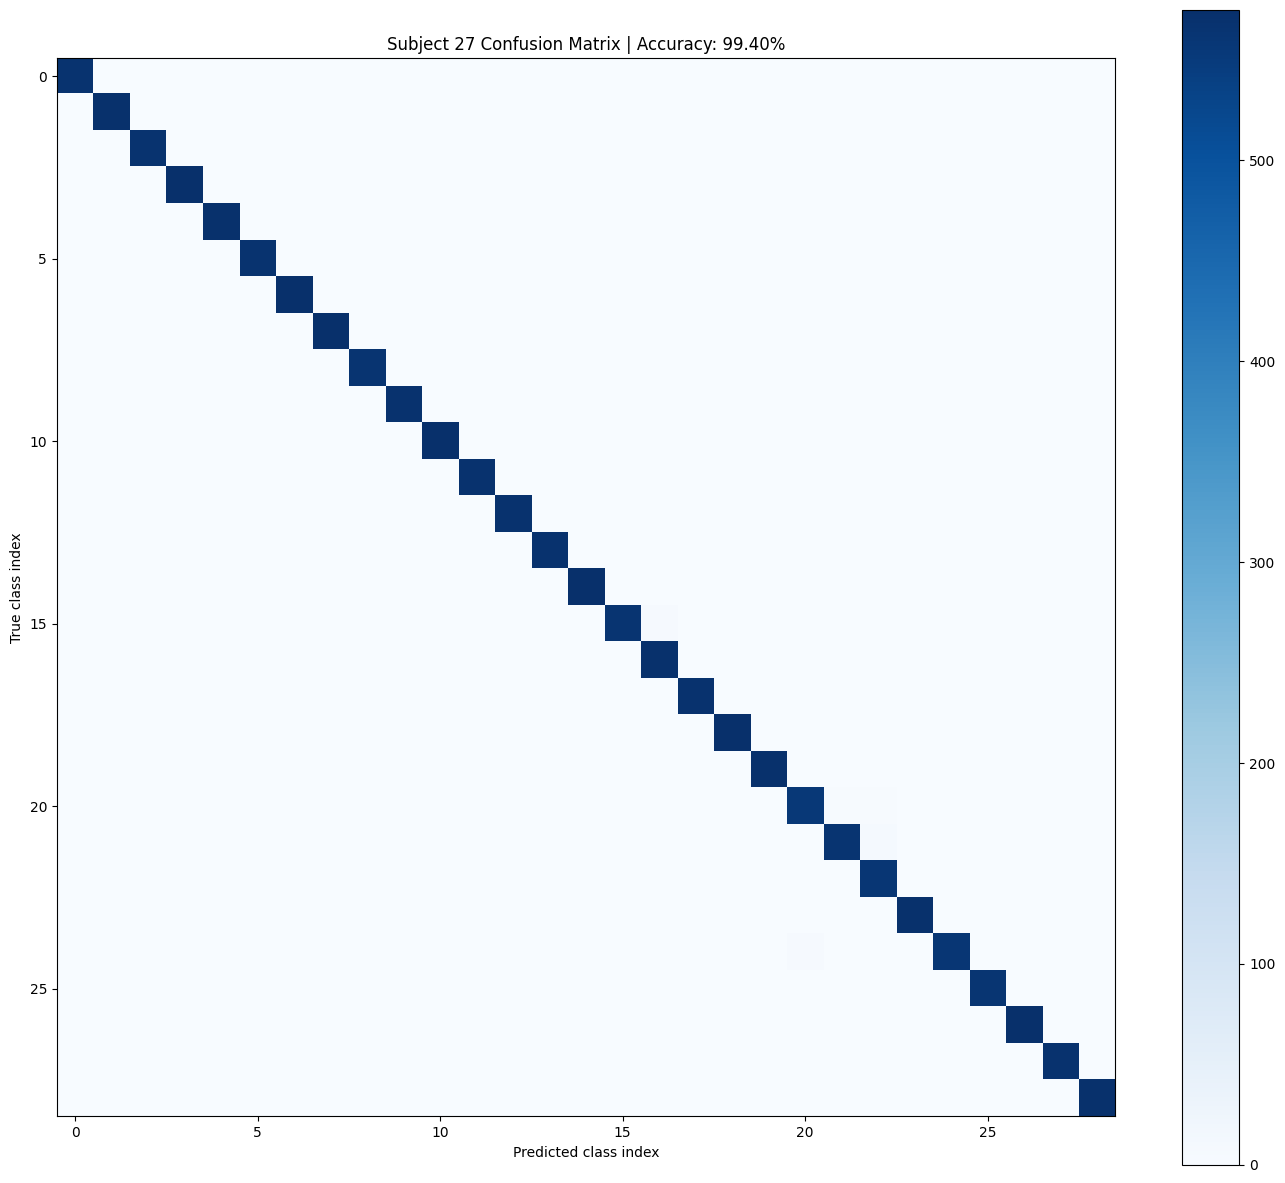

'# Optional: save results to Drive.\nRESULTS_DIR = os.path.join(MODEL_DIR, "subject_01_evaluation")\nos.makedirs(RESULTS_DIR, exist_ok=True)\n\nnp.save(os.path.join(RESULTS_DIR, "subject_01_pred_probs.npy"), pred_probs)\nnp.save(os.path.join(RESULTS_DIR, "subject_01_y_true_encoded.npy"), y_true_encoded)\nnp.save(os.path.join(RESULTS_DIR, "subject_01_y_pred_encoded.npy"), y_pred_encoded)\nnp.save(os.path.join(RESULTS_DIR, "subject_01_confusion_matrix.npy"), cm)\n\nresults = {\n    "subject_id": int(SUBJECT_ID),\n    "accuracy": float(acc),\n    "weighted_f1": float(f1_weighted),\n    "n_windows": int(len(X_subject)),\n    "n_classes_total": int(len(label_classes)),\n    "n_classes_present": int(len(np.unique(y_true_encoded))),\n    "model_dir": MODEL_DIR,\n    "dataset_path": DATASET_PATH,\n}\n\nwith open(os.path.join(RESULTS_DIR, "subject_01_metrics.json"), "w") as f:\n    json.dump(results, f, indent=2)\n\nprint(f"Saved evaluation outputs to: {RESULTS_DIR}")'

In [9]:
# Confusion matrix for Subject 1

cm = confusion_matrix(y_true_encoded, y_pred_encoded, labels=np.arange(len(label_classes)))

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Subject {SUBJECT_ID} Confusion Matrix | Accuracy: {acc * 100:.2f}%")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.colorbar()
plt.tight_layout()
plt.show()

"""# Optional: save results to Drive.
RESULTS_DIR = os.path.join(MODEL_DIR, "subject_01_evaluation")
os.makedirs(RESULTS_DIR, exist_ok=True)

np.save(os.path.join(RESULTS_DIR, "subject_01_pred_probs.npy"), pred_probs)
np.save(os.path.join(RESULTS_DIR, "subject_01_y_true_encoded.npy"), y_true_encoded)
np.save(os.path.join(RESULTS_DIR, "subject_01_y_pred_encoded.npy"), y_pred_encoded)
np.save(os.path.join(RESULTS_DIR, "subject_01_confusion_matrix.npy"), cm)

results = {
    "subject_id": int(SUBJECT_ID),
    "accuracy": float(acc),
    "weighted_f1": float(f1_weighted),
    "n_windows": int(len(X_subject)),
    "n_classes_total": int(len(label_classes)),
    "n_classes_present": int(len(np.unique(y_true_encoded))),
    "model_dir": MODEL_DIR,
    "dataset_path": DATASET_PATH,
}

with open(os.path.join(RESULTS_DIR, "subject_01_metrics.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved evaluation outputs to: {RESULTS_DIR}")"""

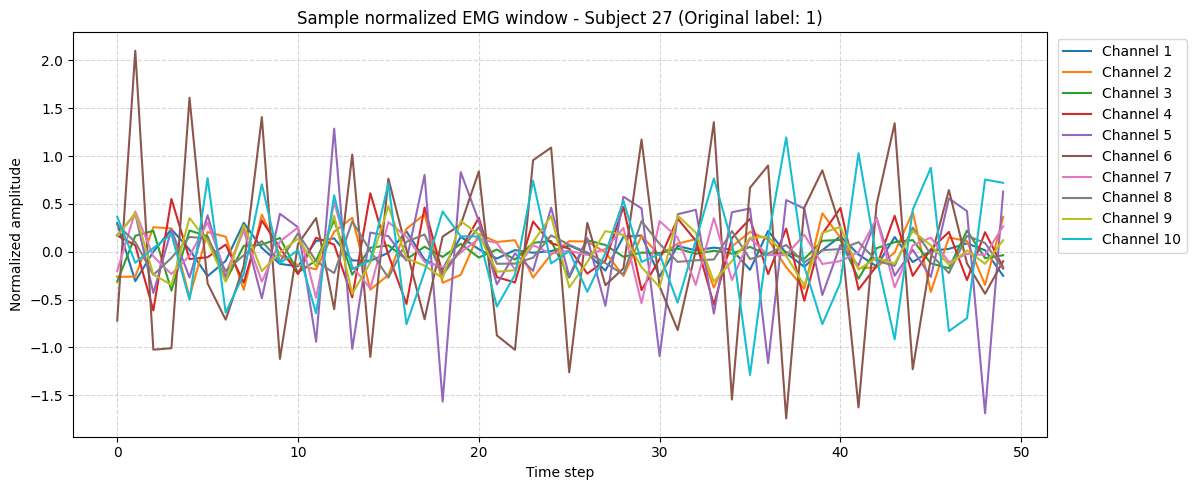

In [10]:
# Plot one normalized, preprocessed EMG window from Subject 1

sample_idx = 0
plt.figure(figsize=(12, 5))
plt.plot(X_subject[sample_idx])
plt.title(
    f"Sample normalized EMG window - Subject {SUBJECT_ID} "
    f"(Original label: {y_true_original[sample_idx]})"
)
plt.xlabel("Time step")
plt.ylabel("Normalized amplitude")
plt.legend([f"Channel {i + 1}" for i in range(X_subject.shape[2])], loc="upper right", bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
